# Defining the Goal

We want to analyze the data collected from data analysis job postings program in order to determine how many data analyst positions were offered since the start of the war (Iran-Israel 2026), and to identify key patterns and trends in the job market during this period.

# Data Collection

**Import data**

In [23]:
import pandas as pd

In [24]:
import numpy as np
import matplotlib.pyplot as plt

In [25]:
df = pd.read_excel("Job Listings Database.xlsx")

# Preparing and cleaning the Data 

In [26]:
# data info() for general information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568 entries, 0 to 567
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Title            567 non-null    object 
 1   Job Description  567 non-null    object 
 2   Platform         568 non-null    object 
 3   Link             567 non-null    object 
 4   Date             567 non-null    object 
 5   Rating           568 non-null    int64  
 6   Fit for the job  568 non-null    int64  
 7   Reasoning        568 non-null    object 
 8   Company Name     567 non-null    object 
 9   Cover Letter     324 non-null    object 
 10  City             563 non-null    object 
 11  Expired          553 non-null    float64
 12  Remote           553 non-null    float64
 13  Status           568 non-null    object 
dtypes: float64(2), int64(2), object(10)
memory usage: 62.2+ KB


In [27]:
# take a look at the data frame
display(df.head(1))

,Title,Job Description,Platform,Link,Date,Rating,Fit for the job,Reasoning,Company Name,Cover Letter,City,Expired,Remote,Status
0,Data Analyst- Student Position,Fiverr is looking for a talented student to jo...,Indeed,https://www.indeed.com/viewjob?jk=a438a8f956a2...,2026-02-23,4,2,Breakdown by rubric: a) Fit (2/4): Candidate h...,Fiverr,"Dear Hiring Team,\n\nMy name is Ruth Benzaquen...",תל אביב -יפו,0.0,0.0,Not interested


In [28]:
# lower case all the column names, to make the work easier 
for i in df:
    df = df.rename(columns= { i : i.lower()})

In [29]:
# take a look!
df.head(1)

,title,job description,platform,link,date,rating,fit for the job,reasoning,company name,cover letter,city,expired,remote,status
0,Data Analyst- Student Position,Fiverr is looking for a talented student to jo...,Indeed,https://www.indeed.com/viewjob?jk=a438a8f956a2...,2026-02-23,4,2,Breakdown by rubric: a) Fit (2/4): Candidate h...,Fiverr,"Dear Hiring Team,\n\nMy name is Ruth Benzaquen...",תל אביב -יפו,0.0,0.0,Not interested


In [30]:
# in order to display all rows in a result
pd.set_option('display.max_rows', None)

In [31]:
#value counts of some 'suspicious' columns
list_columns_value_counts = ["city", "status","expired", "remote"]
value_counts = ""

for i in list_columns_value_counts:
    value_counts = df[i].value_counts()
    display(value_counts)

city
Tel Aviv-Yafo, Tel Aviv District, Israel         133
תל אביב -יפו                                      52
Tel Aviv District, Israel                         46
Center District, Israel                           42
Petah Tikva, Center District, Israel              35
Ramat Gan, Tel Aviv District, Israel              20
Raanana, Center District, Israel                  20
Israel                                            20
Haifa, Haifa District, Israel                     13
פתח תקווה                                         12
Herzliya, Tel Aviv District, Israel               11
רעננה                                             10
Netanya, Center District, Israel                   8
רמת גן                                             8
Rishon LeZion, Center District, Israel             7
נתניה                                              7
Rosh HaAyin, Center District, Israel               6
Jerusalem District, Israel                         6
West Jerusalem, Jerusalem District, Israe

status
Not interested    300
To-Do             244
Applied            24
Name: count, dtype: int64

expired
0.0    542
1.0     11
Name: count, dtype: int64

remote
0.0    503
1.0     50
Name: count, dtype: int64

**Take aways** 
* city: names in hebrew, 'israel' as result, tel aviv appears 3 times with diferent reference.
* remote: no all the remotes jobs flag true, are really remont jobs. AIAgent adjustment.
* I can make these changes on the AIAgent level.

## Dealing with date data types

In [32]:
# let's a take a quick look at the 'date' column
df["date"]

0               2026-02-23
1               2026-02-23
2               2026-02-24
3               2026-02-24
4               2026-02-24
5               2026-02-24
6               2026-02-24
7               2026-02-24
8               2026-02-24
9               2026-02-23
10              2026-02-23
11              2026-02-23
12              2026-02-23
13              2026-02-23
14              2026-02-23
15              2026-02-23
16              24/02/2026
17              25/02/2026
18              24/02/2026
19              24/02/2026
20              25/02/2026
21              2026-03-01
22              2026-03-01
23              2026-03-01
24              2026-03-01
25              2026-03-01
26     2026-03-01 00:00:00
27     2026-02-26 00:00:00
28              2026-03-01
29              2026-03-01
30              2026-03-01
31              2026-03-01
32              2026-03-01
33              2026-03-01
34              2026-03-01
35              2026-03-01
36              2026-02-28
3

**Take aways**

* There is a big mismatch in the date column because of the changes that were made while manipulating the data, defining the data types, and determining how the results populate this table. This is something we can and should correct before continuing with these steps. From the beginning, we should standardize a specific format for collecting the data and for performing aggregations and manipulations.


**In Israel the war started at 7:30am  28 of February 2026**
* we will manually cut  out the dates bofere the start of the war, and deal with this data types issues later
* we are going to leave out the first day of the war (2026-02-28) since we also want to see it backwards and weekly  - "the last two weeks" 

In [33]:
# from index row 21, first cut
df_war_time = df.iloc[21:]
df_war_time.head(1)

,title,job description,platform,link,date,rating,fit for the job,reasoning,company name,cover letter,city,expired,remote,status
21,Junior Research Analyst,(Entry-Level | No Prior Experience Required)St...,LinkedIn,https://il.linkedin.com/jobs/view/junior-resea...,2026-03-01,5,4,a) Fit = 4: Candidate is an excellent match — ...,StoreNext,"Dear Hiring Team,\n\nMy name is Ruth Benzaquen...","Petah Tikva, Center District, Israel",0.0,0.0,Not interested


In [34]:
# drop values betweens indexes (included) 49 to 59
indices_to_drop = np.arange(49,60) 
df_war_time = df_war_time.drop(indices_to_drop)

In [35]:
# in case you want to check the results
df_war_time.head(1)

,title,job description,platform,link,date,rating,fit for the job,reasoning,company name,cover letter,city,expired,remote,status
21,Junior Research Analyst,(Entry-Level | No Prior Experience Required)St...,LinkedIn,https://il.linkedin.com/jobs/view/junior-resea...,2026-03-01,5,4,a) Fit = 4: Candidate is an excellent match — ...,StoreNext,"Dear Hiring Team,\n\nMy name is Ruth Benzaquen...","Petah Tikva, Center District, Israel",0.0,0.0,Not interested


In [36]:
# drop values between indexes (included) 26 to 27
indices_to_drop = np.arange(26,28)
df_war_time = df_war_time.drop(indices_to_drop) 

In [37]:
# in case you want to check the results
df_war_time.loc[25:29]

,title,job description,platform,link,date,rating,fit for the job,reasoning,company name,cover letter,city,expired,remote,status
25,Data Analyst,About BuildotsBuildots is transforming constru...,LinkedIn,https://il.linkedin.com/jobs/view/data-analyst...,2026-03-01,7,4,Fit (4/4): Candidate meets core requirements —...,Buildots,"Dear Hiring Team,\n\nMy name is Ruth Benzaquen...","Tel Aviv District, Israel",0.0,0.0,Applied
28,Fraud & Risk Analyst,About The CompanyWe are a rapidly expanding mo...,LinkedIn,https://il.linkedin.com/jobs/view/fraud-risk-a...,2026-03-01,6,3,Breakdown: a) Fit = 3: Candidate meets key tec...,Yuval HR,"Dear Hiring Team,\n\nMy name is Ruth Benzaquen...","Tel Aviv-Yafo, Tel Aviv District, Israel",0.0,0.0,Not interested
29,Junior FP&A Analyst,This is an excellent opportunity for an early-...,LinkedIn,https://il.linkedin.com/jobs/view/junior-fp-a-...,2026-03-01,4,3,a) Fit (3/4): Candidate has strong analytical ...,Priority Software,"Dear Hiring Team,\n\nMy name is Ruth Benzaquen...","Rosh HaAyin, Center District, Israel",0.0,0.0,Not interested


In [38]:
# Last we need to drop and we are ready!
df_war_time = df_war_time.drop([36,43])

In [39]:
# in case you want to check the results 
df_war_time.loc[35:44]

,title,job description,platform,link,date,rating,fit for the job,reasoning,company name,cover letter,city,expired,remote,status
35,SOC Analyst,דרוש/ה אנליסט/ית SOC Tier 1 לארגון בריאות גדול...,LinkedIn,https://il.linkedin.com/jobs/view/soc-analyst-...,2026-03-01,3,1,Fit: 1 point — candidate is a data analyst wit...,Confidential Careers,"Dear Hiring Team,\n\nMy name is Ruth Benzaquen...","Tel Aviv District, Israel",1.0,0.0,Not interested
37,Sales Financial Analyst- כלכלן.נית מכירות,Job Descriptionהאגיס®. קלינקס®. קוטקס®. דיפנד®...,LinkedIn,https://il.linkedin.com/jobs/view/sales-financ...,2026-03-05,5,3,Fit (3/4): Candidate has ~3 years of data/anal...,Kimberly-Clark,"Dear Hiring Team,\n\nMy name is Ruth Benzaquen...","Ramla, Center District, Israel",0.0,0.0,Not interested
38,Salesforce System Analyst & Specialist for lea...,We are looking for a skilled System Analyst & ...,LinkedIn,https://il.linkedin.com/jobs/view/salesforce-s...,2026-03-01,2,1,Fit (1/4): Candidate has a relevant B.Sc. and ...,INGIMA,"Dear Hiring Team,\n\nMy name is Ruth Benzaquen...","Center District, Israel",0.0,0.0,Not interested
39,Senior Data Analyst,אנחנו מגייסים Senior Data Analyst לארגון גדול ...,LinkedIn,https://il.linkedin.com/jobs/view/senior-data-...,2026-03-01,4,3,The candidate matches the job's core technical...,Logica-IT,"Dear Hiring Team,\n\nMy name is Ruth Benzaquen...","Haifa, Haifa District, Israel",0.0,0.0,Not interested
40,Senior Data Analyst,לארגון ציבורי גדול בחיפה דרוש/ה Senior Data An...,LinkedIn,https://il.linkedin.com/jobs/view/senior-data-...,2026-03-01,3,2,a) Fit (2/4): Candidate matches core technical...,One Systems,"Dear Hiring Team,\n\nMy name is Ruth Benzaquen...","Haifa, Haifa District, Israel",0.0,0.0,Not interested
41,Indirect Tax Analyst,We are looking for a Highly motivated Analyst ...,LinkedIn,https://il.linkedin.com/jobs/view/indirect-tax...,2026-03-01,3,3,Fit (3/4): Candidate has a B.Sc. in a quantita...,Global-e,"Dear Hiring Team,\n\nMy name is Ruth Benzaquen...","Petah Tikva, Center District, Israel",0.0,0.0,Not interested
42,Financial Analysis Expert,Job ID: 207951Required Travel :MinimalManageri...,LinkedIn,https://il.linkedin.com/jobs/view/financial-an...,2026-03-01,2,1,Breakdown: a) Fit = 1 point. The candidate is ...,Amdocs,"Dear Hiring Team,\n\nMy name is Ruth Benzaquen...","Raanana, Center District, Israel",0.0,0.0,Not interested
44,"MIS Specialist – Systems, Automations & Integr...",AboutCandex is a rapidly growing private globa...,LinkedIn,https://il.linkedin.com/jobs/view/mis-speciali...,2026-03-03,9,3,a) Fit (3/4): Candidate has 3+ years of releva...,Candex,"Dear Hiring Team,\n\nMy name is Ruth Benzaquen...","Ramat Gan, Tel Aviv District, Israel",1.0,0.0,Not interested


In [40]:
# drop all rows with date>2026-03-14
#df_war_time = df_war_time[df_war_time['date'] < "2026-03-14"]

In [41]:
#last check
df_war_time["date"]

21              2026-03-01
22              2026-03-01
23              2026-03-01
24              2026-03-01
25              2026-03-01
28              2026-03-01
29              2026-03-01
30              2026-03-01
31              2026-03-01
32              2026-03-01
33              2026-03-01
34              2026-03-01
35              2026-03-01
37              2026-03-05
38              2026-03-01
39              2026-03-01
40              2026-03-01
41              2026-03-01
42              2026-03-01
44              2026-03-03
45              2026-03-01
46              2026-03-01
47     2026-03-01 00:00:00
48     2026-03-01 00:00:00
60     2026-03-01 00:00:00
61     2026-03-02 00:00:00
62     2026-03-01 00:00:00
63     2026-03-01 00:00:00
64              2026-03-01
65     2026-03-02 00:00:00
66              2026-03-01
67              2026-03-01
68     2026-03-02 00:00:00
69     2026-03-02 00:00:00
70              2026-03-01
71              2026-03-02
72              2026-03-01
7

**Looks perfect! Let's change the data type from object to date data type**

In [42]:
df_war_time['date'] = pd.to_datetime(df_war_time['date'], format = '%Y-%m-%d') 

In [43]:
# let's take a look!
df_war_time['date'].sample()

229   2026-03-05
Name: date, dtype: datetime64[ns]

# Exploratory data analysis

## How many jobs posts where posted since the war started?

### total jobs postings

In [44]:
len(df)

568

In [45]:
len(df_war_time)

532

### jobs postings per day

In [46]:
df_wt_by_day = df_war_time.groupby(['date'])[['title']].count()

In [47]:
df_wt_by_day = df_wt_by_day.reset_index()

In [48]:
# jobs postings per day
df_wt_by_day

,date,title
0,2026-03-01,30
1,2026-03-02,64
2,2026-03-03,38
3,2026-03-04,39
4,2026-03-05,61
5,2026-03-06,21
6,2026-03-07,8
7,2026-03-08,9
8,2026-03-09,41
9,2026-03-10,70


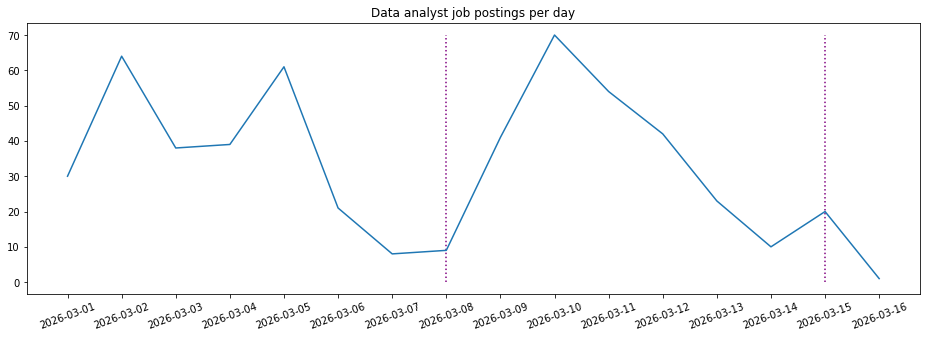

In [68]:
x = np.array(df_wt_by_day['date'])
y = np.array(df_wt_by_day['title'])

plt.figure(figsize=(16,5))
plt.title('Data analyst job postings per day')
plt.plot(x,y)

# Set the x-axis ticks
plt.xticks(x)
# rotate the ticks 
plt.xticks(rotation=20)
# add line to show 'first day of the week'

# Using plt.vlines() for multiple line to show the firt day of the next week
plt.vlines(x=['2026-03-08'], ymin=0, ymax=70, colors='purple', ls=':')
# Using plt.vlines() for multiple line to show the firt day of the last week
plt.vlines(x=['2026-03-15'], ymin=0, ymax=70, colors='purple', ls=':')


plt.show()

### jobs postings per day LinkeIn platform

In [50]:
# check value counts by platform
df_war_time['platform'].value_counts()

platform
LinkedIn    427
Indeed      105
Name: count, dtype: int64

In [51]:
# firlter out Indeed platform and create new data frame to work on
linkeIn_dates =  df_war_time[df_war_time['platform'] == 'LinkedIn']

In [52]:
# Take a look see all it's workings as intended 
linkeIn_dates.sample()

,title,job description,platform,link,date,rating,fit for the job,reasoning,company name,cover letter,city,expired,remote,status
168,Security Operations Center Analyst,Mertens – MalamTeam is hiring a SOC AnalystRol...,LinkedIn,https://il.linkedin.com/jobs/view/security-ope...,2026-03-03,2,1,The resume is primarily a data-analytics backg...,מרטנס | Mertens – מקבוצת מלם תים,"Dear Hiring Team,\n\nMy name is Ruth Benzaquen...","Center District, Israel",0.0,0.0,Not interested


In [53]:
# group by date and count the rows 
linkeIn_dates_groupby = linkeIn_dates.groupby('date')['link'].count()

In [54]:
# reset_index and change the name of the new column 
linkeIn_dates_groupby = linkeIn_dates_groupby.reset_index()
linkeIn_dates_groupby =  linkeIn_dates_groupby.rename(columns= {'link' : 'counts'})
linkeIn_dates_groupby

,date,counts
0,2026-03-01,25
1,2026-03-02,48
2,2026-03-03,30
3,2026-03-04,27
4,2026-03-05,54
5,2026-03-06,20
6,2026-03-07,6
7,2026-03-08,1
8,2026-03-09,33
9,2026-03-10,59


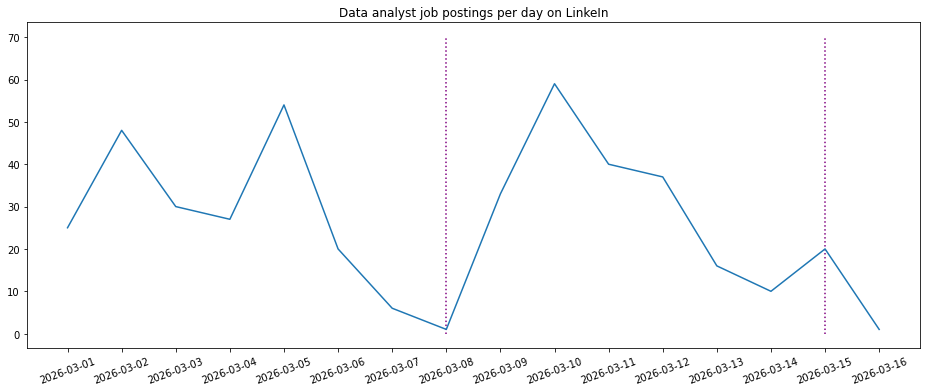

In [67]:
#plot the chart!

# create arrays for the axis x and y
x = np.array(linkeIn_dates_groupby['date'])
y = np.array(linkeIn_dates_groupby['counts'])

plt.figure(figsize = (16,6))
plt.title('Data analyst job postings per day on LinkeIn')
plt.plot(x,y)

# set the x-axis ticks
plt.xticks(x)
# rotate the ticks 
plt.xticks(rotation=20)
# Using plt.vlines() for multiple line to show the first day of week 2
plt.vlines(x=['2026-03-08'], ymin=0, ymax=70, colors='purple', ls= ':')
# Using plt.vlines() for multiple line to show the first day of week 3
plt.vlines(x=['2026-03-15'], ymin=0, ymax=70, colors='purple', ls= ':')

# plot
plt.show()

### job postings per week

In [56]:
df_wt_by_day_week = df_wt_by_day

In [57]:
# strftime() method is used to return the week number of the year, treating Sunday as the first day of the week
df_wt_by_day_week['week'] = df_wt_by_day_week['date'].dt.strftime('%U')

In [58]:
# Let's take a look
df_wt_by_day_week.tail(2)

,date,title,week
14,2026-03-15,20,11
15,2026-03-16,1,11


In [59]:
# name column 'title' to 'counts'
df_wt_by_day_week = df_wt_by_day_week.rename(columns={"title": "counts"})
df_wt_by_day_week.head(1)

,date,counts,week
0,2026-03-01,30,09


In [60]:
#job postings per week
df_wt_by_week = df_wt_by_day_week.groupby('week')['counts'].sum().reset_index()
df_wt_by_week

,week,counts
0,09,261
1,10,249
2,11,21


## How many of these job I'm a perfect 'fit for the job'?

In [61]:
# jobs postings during war with a 'fit for the job' equals 4 (max ratings)
df_war_time_fit = df_war_time[df_war_time['fit for the job'] == 4]

In [62]:
# total of these jobs postings and 4 for 'fir for the job'
len(df_war_time_fit) 

53

In [63]:
print(len(df_war_time)/len(df_war_time_fit))

10.037735849056604


In [64]:
print(len(df_war_time_fit)*100/len(df_war_time))

9.962406015037594


In [65]:
len(df_war_time)

532